# Nebenwirkungen? Keras kann es vorhersagen

In diesem Projekt habe ich eine kleine End-to-End-Machine-Learning-Pipeline mit TensorFlow/Keras, Scikit-Learn und NumPy aufgebaut, um eine hypothetische klinische Studie zu modellieren. Ziel war es, Patientendaten zu simulieren, ein neuronales Netzwerk zu trainieren und seine Fähigkeit zu bewerten, vorherzusagen, ob einzelne Personen Nebenwirkungen eines neuen Medikaments entwickeln würden.

Obwohl das Beispiel vereinfacht ist, zeigt dieses Projekt den vollständigen Workflow, der für den Einsatz eines Machine-Learning-Modells erforderlich ist:
Datengenerierung → Preprocessing → Modelldesign → Training → Evaluation → Interpretation.

In dieser Studie wurde ein neues klinisches Medikament an Personen im Alter von 18 bis 100 Jahren getestet. Von den insgesamt 2100 Teilnehmern war die Hälfte unter 65 Jahre alt und die andere Hälfte über 65 Jahre alt. 
Von diesen:
- hatten etwa 95 % der Patienten ab 65 Jahren Nebenwirkungen
- zeigten etwa 95 % der Patienten unter 65 Jahren keine Nebenwirkungen 

Libraries laden

In [ ]:
import numpy as np
import pandas as pd
from random import randint 
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4, 3]

# for ML
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy

### 1. Datengenerierung


In [5]:
train_labels = []
train_samples = []

# die 5 % der Daten generieren
for i in range(50):
    # 5 % junge Menschen mit Nebenwirkungen 
    random_younger = randint(18,64)
    train_samples.append(random_younger)
    train_labels.append(1) #1 = Nebenwirkungen, 0 = keine Nebenwirkungen 

    # 5 % ältere Menschen ohne Nebenwirkungen 
    random_older = randint(65,100)
    train_samples.append(random_older)
    train_labels.append(0)

# die restlichen Daten generieren 
for i in range(1000):
    #95 % junge ohne Nebenwirkungen
    random_younger = randint(18,64)
    train_samples.append(random_younger)
    train_labels.append(0)

    #95% ältere mit Nebenwirkungen 
    random_older = randint(65,100)
    train_samples.append(random_older)
    train_labels.append(1)
    

Wir überprüfen die generierten Daten.

In [6]:
print('Biespielalter')
print(train_samples[1:5])
print('Nebenwirkungen')
print(train_labels[1:5])

Biespielalter
[92, 29, 72, 51]
Nebenwirkungen
[0, 1, 0, 1]


Wir können die Statistik der generierten Daten visualisieren.

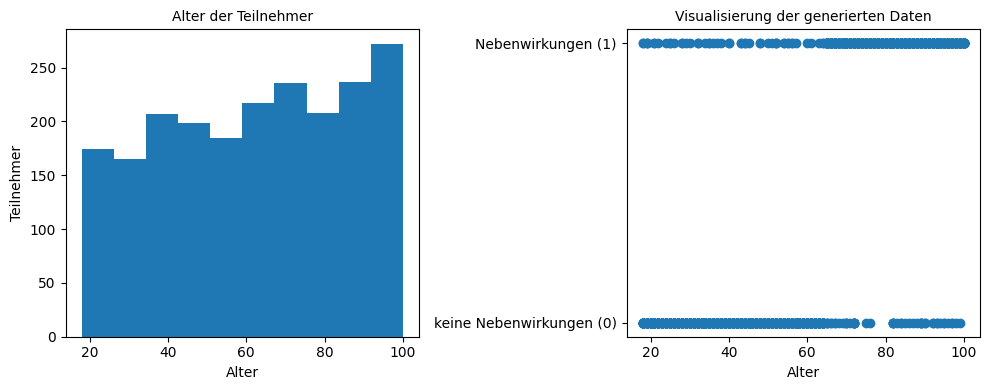

In [7]:
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
# Alter der Teilnehmer
ax[0].hist(train_samples)
ax[0].set_title('Alter der Teilnehmer', fontsize = 10)
ax[0].set_xlabel('Alter',fontsize = 10)
ax[0].set_ylabel('Teilnehmer',fontsize = 10)


# Visualisierung der generierten Daten - Alter der Teilnehmer und Auftreten von Nebenwirkungen 
ax[1].scatter(train_samples,train_labels)
ax[1].set_title('Visualisierung der generierten Daten', fontsize = 10)
ax[1].set_xlabel('Alter',fontsize = 10)
ax[1].set_yticks([0, 1])
ax[1].set_yticklabels(['keine Nebenwirkungen (0)', 'Nebenwirkungen (1)'])

plt.tight_layout()
plt.show()


Um die Daten zum Trainieren des Modells zu verwenden, müssen wir sie in ein Numpy-Array umwandeln. Es empfiehlt sich, die einzelnen Datenpunkte zu vermischen, um Verzerrungen zu vermeiden. 

In [8]:
train_labels = np.array(train_labels)
train_samples = np.array(train_samples)

train_labels, train_samples = shuffle(train_labels, train_samples)

Um die Berechnung für das neuronale Netzwerk zu vereinfachen, werde ich das Alter von 0 bis 1 normalisieren. 

In [9]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train_samples = scaler.fit_transform(train_samples.reshape(-1,1)) #we use this since our data is 1D

### 2. Modellerstellung

Ich werde ein Modell für die sequenzielle Klasse verwenden.
Wir haben die Eingabeschicht (aus den von uns generierten Daten), gefolgt von drei versteckten Schichten.

Die Anzahl der Knoten in jeder Schicht ist beliebig und wird im Code als Einheiten (units) definiert.

Die letzte Schicht hat zwei Schichten, da ich eine Ausgabe von entweder 0 oder 1 (Nebenwirkung oder keine Nebenwirkung) haben möchte.

In [10]:
model = Sequential([
    Dense(units=6, input_shape=(1,), activation='relu'),
    Dense(units=12, activation='relu'),
    Dense(units=2, activation = 'softmax') #fully connected
])

/Users/leticia/miniconda3/envs/hackathon/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Visuelle Zusammenfassung der Modellarchitektur 

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122 (488.00 B)

 Trainable params: 122 (488.00 B)

 Non-trainable params: 0 (0.00 B)

### 3. Modelltraining

Jetzt, da wir ein Netzwerk haben, werde ich die zuvor erstellten und verarbeiteten Daten zum Trainieren dieses Modells einfügen. 

Model compiling

In [12]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#### Modelltraining und Validierung


Ist das Modell in der Lage, aus den Daten zu generalisieren? Wichtig ist, sicherzustellen, dass es nicht überanpasst. 

Dazu werde ich 10 % unserer generierten Daten in einen Validierungssatz aufteilen. 

In [13]:
history_val = model.fit(x=scaled_train_samples, 
                    y=train_labels,
                    validation_split = 0.1,
                    batch_size=10, 
                    epochs=30, 
                    shuffle=True, 
                    verbose = 2)

Epoch 1/30
189/189 - 2s - 9ms/step - accuracy: 0.5339 - loss: 0.6506 - val_accuracy: 0.4714 - val_loss: 0.6588
Epoch 2/30
189/189 - 0s - 890us/step - accuracy: 0.5804 - loss: 0.6410 - val_accuracy: 0.5286 - val_loss: 0.6496
Epoch 3/30
189/189 - 0s - 1ms/step - accuracy: 0.6085 - loss: 0.6313 - val_accuracy: 0.5810 - val_loss: 0.6399
Epoch 4/30
189/189 - 0s - 1ms/step - accuracy: 0.6376 - loss: 0.6212 - val_accuracy: 0.6048 - val_loss: 0.6294
Epoch 5/30
189/189 - 0s - 925us/step - accuracy: 0.6661 - loss: 0.6107 - val_accuracy: 0.6238 - val_loss: 0.6189
Epoch 6/30
189/189 - 0s - 883us/step - accuracy: 0.6889 - loss: 0.5995 - val_accuracy: 0.6571 - val_loss: 0.6071
Epoch 7/30
189/189 - 0s - 883us/step - accuracy: 0.7058 - loss: 0.5878 - val_accuracy: 0.6952 - val_loss: 0.5945
Epoch 8/30
189/189 - 0s - 877us/step - accuracy: 0.7222 - loss: 0.5755 - val_accuracy: 0.7381 - val_loss: 0.5807
Epoch 9/30
189/189 - 0s - 871us/step - accuracy: 0.7540 - loss: 0.5626 - val_accuracy: 0.7571 - val_lo

Hier können wir die Modellgenauigkeit und den Verlust im Zeitverlauf sowohl für die Trainingsdaten (rot) als auch für die Validierungsdaten (blau) visualisieren.

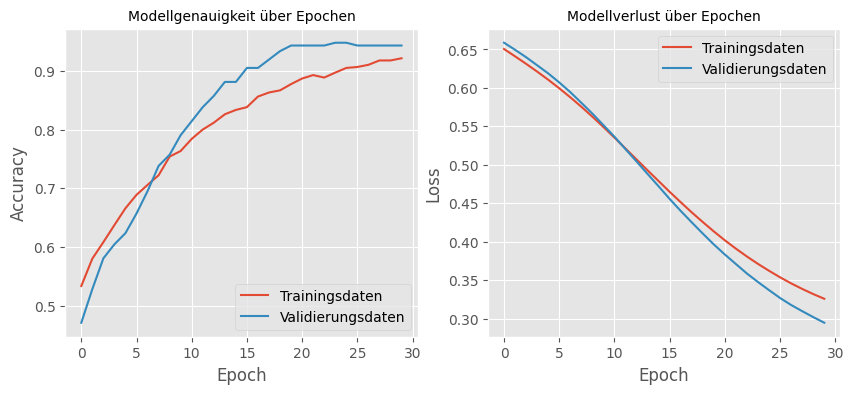

In [14]:
plt.style.use('ggplot')
fig, ax = plt.subplots(ncols=2, figsize=(10,4))

#first plot 
ax[0].plot(history_val.history['accuracy'], label = 'Trainingsdaten')
ax[0].plot(history_val.history['val_accuracy'], label = 'Validierungsdaten')
ax[0].set_title('Modellgenauigkeit über Epochen',fontsize = 10)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

#second plot
ax[1].plot(history_val.history['loss'], label = 'Trainingsdaten')
ax[1].plot(history_val.history['val_loss'], label = 'Validierungsdaten')
ax[1].set_title('Modellverlust über Epochen',fontsize = 10)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()


Da sowohl die Trainings- als auch die Validierungsgenauigkeit mit der Zeit zunimmt, scheint es wie erwartet so, als würde das Modell die Trainingsdaten nicht überanpassen.

### 4. Modell als Schlussfolgerung

Nachdem das Modell nun trainiert und validiert wurde, können wir es verwenden, um Rückschlüsse auf Daten zu ziehen, die es zuvor noch nicht gesehen hat.

Um dies zu testen, erstellen wir auf ähnliche Weise wie bei den Trainingsdaten einen Testsatz.


In [15]:
test_labels = []
test_samples = []

# generate the 5% of data
for i in range(10):
    # 5% younger with side effects 
    random_younger = randint(18,64)
    test_samples.append(random_younger)
    test_labels.append(1) #1 means side effects and 0 no side effects 

    # 5% older without side effects 
    random_older = randint(65,100)
    test_samples.append(random_older)
    test_labels.append(0)

# generate the rest of the data 
for i in range(200):
    #95% younger without side effects
    random_younger = randint(18,64)
    test_samples.append(random_younger)
    test_labels.append(0)

    #95% older with side effects
    random_older = randint(65,100)
    test_samples.append(random_older)
    test_labels.append(1)
    
test_labels = np.array(test_labels)
test_samples = np.array(test_samples)
test_labels, test_samples = shuffle(test_labels, test_samples)
scaled_test_samples = scaler.fit_transform(test_samples.reshape(-1,1))

Modellvorhersage

In [16]:
predictions = model.predict(x=scaled_test_samples, batch_size=10, verbose=0)

Die Vorhersage:
Für jedes Element im Testsatz haben wir eine Wahrscheinlichkeit, die angibt, ob der Patient eine Nebenwirkung hat oder nicht. 

In [17]:
for i in predictions[1:5]:
    print(i)

[0.52316254 0.4768375 ]
[0.21558203 0.784418  ]
[0.05693188 0.94306815]
[0.8363961 0.1636039]


Den Parameter mit der höchsten Wahrscheinlichkeit können wir erhalten. 

In [18]:
rounded_predictions = np.argmax(predictions, axis=-1)
for i in rounded_predictions[1:5]:
    print(i)

0
1
1
0


#### Modellgenauigkeit

Wir können die Genauigkeit des Modells mithilfe einer Verwechslungsmatrix visualisieren. 

In [19]:
from sklearn.metrics import confusion_matrix
import itertools

In [20]:
cm = confusion_matrix(y_true=test_labels, y_pred=rounded_predictions)

In [21]:
def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = 'Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation= 'nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks,classes)
    
    if normalize:
        cm = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
        
    thresh = cm.max() / 2
    
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i, cm[i,j],
                 horizontalalignment='center',
                 color='white' if cm[i,j] > thresh else 'black')
    
    plt.tight_layout()
    plt.ylabel('Tatsächliche Klasse')
    plt.xlabel('Vorhergesagter Wert')


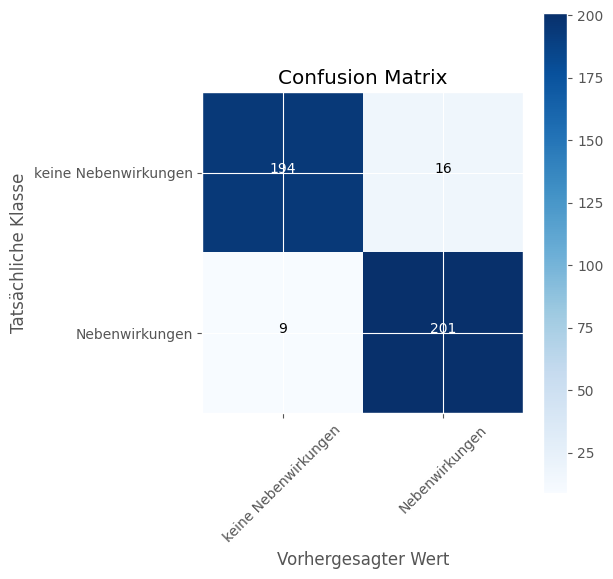

In [24]:
plt.rcParams['figure.figsize'] = [6, 6]
cm_plot_labels = ['keine Nebenwirkungen', 'Nebenwirkungen']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title = 'Confusion Matrix')

Die finale Konfusionsmatrix zeigt, dass das Modell sehr gut darin ist, vorherzusagen, ob ein Patient Nebenwirkungen haben wird – basierend ausschließlich auf dem Alter. Von allen Testsamples identifizierte das Netzwerk 174 Patienten korrekt ohne Nebenwirkungen und 202 Patienten korrekt mit Nebenwirkungen, was auf eine insgesamt hohe Klassifikationsgenauigkeit hinweist. Das Modell erzeugte 36 falsch positive Vorhersagen (Patienten, die fälschlicherweise als „mit Nebenwirkungen“ eingestuft wurden) und 8 falsch negative Vorhersagen (Patienten, die fälschlicherweise als „ohne Nebenwirkungen“ eingestuft wurden).

Diese Ergebnisse zeigen, dass das Modell das zugrunde liegende altersabhängige Muster wirksam gelernt hat. Besonders wichtig im medizinischen Kontext ist die relativ geringe Zahl an falsch negativen Vorhersagen, da das Unterschätzen des Risikos von Nebenwirkungen kritischer ist als eine Übervorsicht. Die vorhandenen falsch positiven Ergebnisse sind in diesem vereinfachten Szenario akzeptabel, da sie eher auf der sicheren Seite liegen.

Insgesamt bestätigt die Konfusionsmatrix, dass selbst ein einfaches neuronales Netzwerk die starke Beziehung zwischen Alter und Medikamentenverträglichkeit in dieser simulierten Studie erfolgreich generalisieren kann. Dies unterstreicht das Potenzial von Machine-Learning-Modellen, die frühe Risikobewertung und Entscheidungsfindung in klinischen und pharmazeutischen Anwendungen zu unterstützen.